# DE1 Homework

In [7]:
import pandas as pd

# Import the TSV file
df = pd.read_csv('id-tourism-sentimentanalysis.tsv', sep='\t')
df.head()

,no,review,sentiment
0,1,bosen singgah pagi siang sore malam ramai keli...,positive
1,2,sedia parkir luas resto tata apik rapi pandang...,positive
2,3,kamar bersih luas staf ramah lokasi guesthouse...,positive
3,4,malang menajubkan lihat kampung warna wrni ni ...,positive
4,5,masjid bersih kota malang letak berangan alun ...,positive


## AWS Translation

In [8]:
from pprint import PrettyPrinter

import boto3

print("📚 Setting up the environment...")
pp = PrettyPrinter(indent=2)
translate = boto3.client("translate")
print("✅ Environment setup complete!")
print(f"🌍 Using AWS region: {translate.meta.region_name}")

📚 Setting up the environment...
✅ Environment setup complete!
🌍 Using AWS region: eu-west-1


In [ ]:
# Translate reviews to English
def translate_text(text, source_lang='auto', target_lang='en'):
    """Translate text from source language to target language"""
    response = translate.translate_text(
        Text=text,
        SourceLanguageCode=source_lang,
        TargetLanguageCode=target_lang
    )
    return response['TranslatedText']

# Apply translation to the review column
df['review_english'] = df['review'].apply(translate_text)

# Display first few translated reviews
print("Sample translations:")
for idx in range(min(3, len(df))):
    print(f"\n🇪 Original: {df['review'].iloc[idx]}")
    print(f"🇬🇧 English: {df['review_english'].iloc[idx]}")

Sample translations:

🇪🇸 Spanish: bosen singgah pagi siang sore malam ramai keliling jalan lingkar bundar ramai kendara jarang alun alun bundar keliling gedung dpr kantor balaikota hotel tugu sekolah favorit destinasi wisata kuliner hehe
🇬🇧 English: Boren stop in the morning noon afternoon at night crowded round ring road crowded roundabout square round square round square around parliament building office balaikota hotel tugu school favorite culinary tourist destination hehe

🇪🇸 Spanish: sedia parkir luas resto tata apik rapi pandang indah sedia agam menu nusantara es campur segarr angsle porsi relatif cocok potret suasana santai
🇬🇧 English: spacious parking lot resto tidy layout beautiful view ready to go menu archipelago ice mixed fresh angsle portion relatively suitable portrait relaxed atmosphere

🇪🇸 Spanish: kamar bersih luas staf ramah lokasi guesthouse kota strategis sarap variasi biasa aja harga yg pesan booking com lebih murah tidak sarap lebih langsung booking guesthousenya


## AWS Comprehend

In [11]:
comprehend = boto3.client(service_name="comprehend", region_name="eu-west-1")

In [12]:
# Detect sentiment for each review using Comprehend
def detect_sentiment(text):
    """Detect sentiment from text using AWS Comprehend"""
    response = comprehend.detect_sentiment(Text=text, LanguageCode='en')
    return response['Sentiment']

# Apply sentiment analysis to the English reviews
df['sentiment_comprehend'] = df['review_english'].apply(detect_sentiment)

# Display sample sentiments
print("Sample sentiments:")
for idx in range(min(3, len(df))):
    print(f"\nReview {idx + 1}: {df['review_english'].iloc[idx][:100]}...")
    print(f"Sentiment: {df['sentiment_comprehend'].iloc[idx]}")

Sample sentiments:

Review 1: Boren stop in the morning noon afternoon at night crowded round ring road crowded roundabout square ...
Sentiment: POSITIVE

Review 2: spacious parking lot resto tidy layout beautiful view ready to go menu archipelago ice mixed fresh a...
Sentiment: POSITIVE

Review 3: Clean rooms spacious staff friendly location guesthouse strategic city eat usual variety only cheape...
Sentiment: POSITIVE


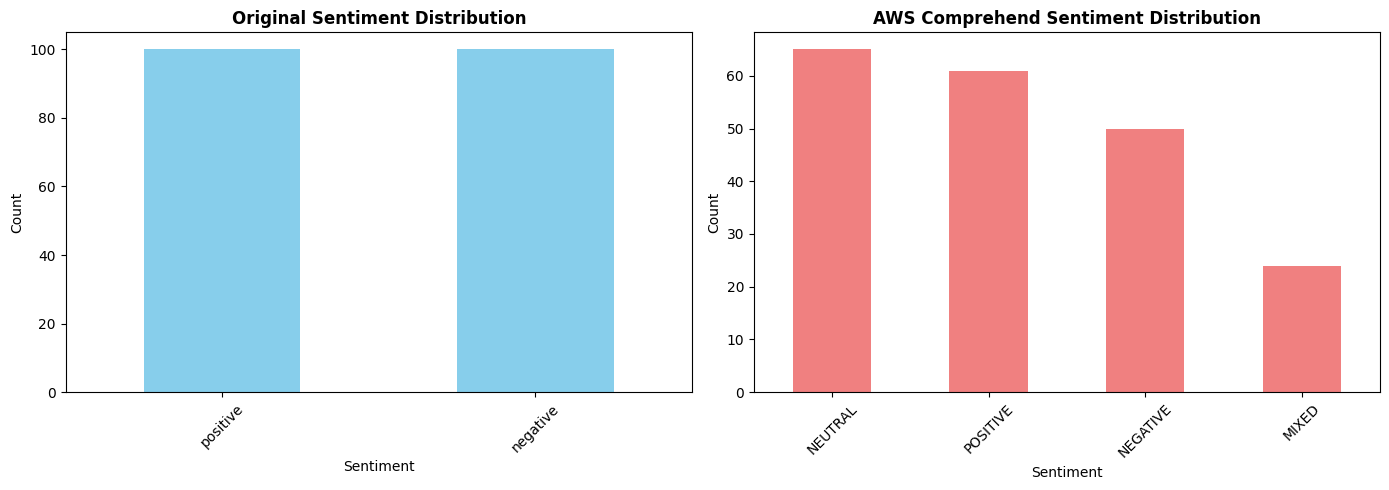


📊 Sentiment Comparison:

Original Sentiment:
sentiment
positive    100
negative    100
Name: count, dtype: int64

Comprehend Sentiment:
sentiment_comprehend
NEUTRAL     65
POSITIVE    61
NEGATIVE    50
MIXED       24
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original sentiment distribution
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Original Sentiment Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Comprehend sentiment distribution
df['sentiment_comprehend'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('AWS Comprehend Sentiment Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print comparison statistics
print("\n📊 Sentiment Comparison:")
print(f"\nOriginal Sentiment:\n{df['sentiment'].value_counts()}")
print(f"\nComprehend Sentiment:\n{df['sentiment_comprehend'].value_counts()}")

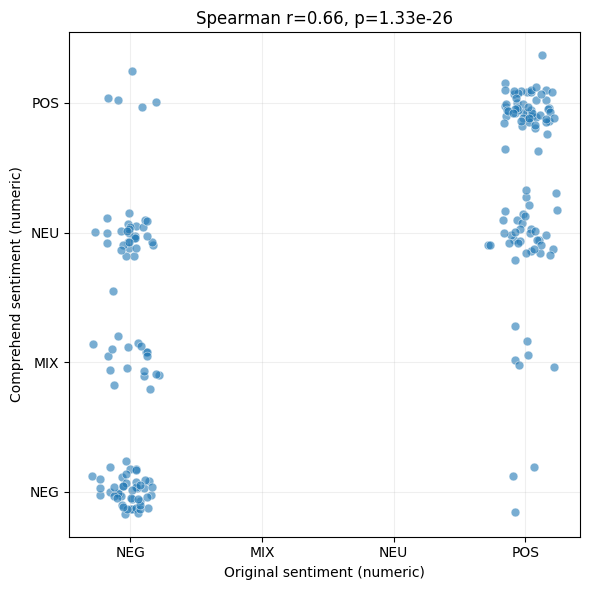

In [15]:
import numpy as np
import seaborn as sns

# Map sentiment labels to numeric scores
mapping = {'NEGATIVE': 1, 'MIXED': 2, 'NEUTRAL': 3, 'POSITIVE': 4}
orig = df['sentiment'].astype(str).str.upper().map(mapping)
comp = df['sentiment_comprehend'].astype(str).str.upper().map(mapping)
plot_df = pd.DataFrame({'orig': orig, 'comp': comp}).dropna()
if plot_df.empty:
    print('No paired sentiment values to plot.')
else:
    # jitter for visibility
    rng = np.random.default_rng(0)
    x = plot_df['orig'] + rng.normal(0, 0.12, size=len(plot_df))
    y = plot_df['comp'] + rng.normal(0, 0.12, size=len(plot_df))

    # Spearman correlation
    try:
        from scipy.stats import spearmanr
        r, p = spearmanr(plot_df['orig'], plot_df['comp'])
    except Exception:
        r = plot_df['orig'].corr(plot_df['comp'], method='spearman')
        p = None

    plt.figure(figsize=(6,6))
    sns.scatterplot(x=x, y=y, alpha=0.6, s=40)
    plt.xlabel('Original sentiment (numeric)')
    plt.ylabel('Comprehend sentiment (numeric)')
    title = f'Spearman r={r:.2f}' + (f', p={p:.3g}' if p is not None else '')
    plt.title(title)
    ticks = [1,2,3,4]
    labels = ['NEG','MIX','NEU','POS']
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## AWS Bedrock

In [16]:
bedrock = boto3.client("bedrock-runtime")
MODEL_ID = "eu.amazon.nova-micro-v1:0"